<a href="https://colab.research.google.com/github/vijaydevverse/eda-ml-projects/blob/main/OnlineShoppersPurchaseEdaV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [30]:
df=pd.read_csv('/content/online_shoppers.csv')
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.000000,0,0.000000,0.016765,0.085003,3.191731,0.000000,2,1,1,1,Nov,Returning_Visitor,False,False
1,3,140.433150,0,121.793138,55,2333.187358,0.000000,0.034682,0.000000,0.221186,3,3,3,5,Dec,Returning_Visitor,False,False
2,2,169.063012,1,72.697027,23,1448.426947,0.068493,0.075369,0.000000,0.000000,2,2,2,12,Sep,Returning_Visitor,False,False
3,4,129.698301,1,118.581521,53,1238.760755,0.024336,0.049339,14.476824,0.124415,1,1,4,8,May,New_Visitor,False,False
4,2,214.526081,2,235.043689,37,297.590433,0.001517,0.018661,37.270547,0.071883,3,4,5,9,Nov,Returning_Visitor,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999994,5,145.040629,0,116.976540,111,3390.402343,0.000000,0.000000,0.000000,0.000000,2,1,7,1,May,New_Visitor,False,False
999995,0,0.000000,1,82.310616,0,0.000000,0.128995,0.183235,0.000000,0.216012,1,2,1,7,Mar,Returning_Visitor,False,False
999996,2,68.850234,0,0.000000,13,0.000000,0.072351,0.085056,8.755833,0.000000,2,4,4,1,Mar,Returning_Visitor,False,False
999997,5,0.000000,0,97.971941,35,1696.862699,0.024662,0.051551,11.351870,0.198211,2,3,1,7,May,Returning_Visitor,False,True


In [31]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Administrative           999999 non-null  int64  
 1   Administrative_Duration  999999 non-null  float64
 2   Informational            999999 non-null  int64  
 3   Informational_Duration   999999 non-null  float64
 4   ProductRelated           999999 non-null  int64  
 5   ProductRelated_Duration  999999 non-null  float64
 6   BounceRates              999999 non-null  float64
 7   ExitRates                999999 non-null  float64
 8   PageValues               999999 non-null  float64
 9   SpecialDay               999999 non-null  float64
 10  OperatingSystems         999999 non-null  int64  
 11  Browser                  999999 non-null  int64  
 12  Region                   999999 non-null  int64  
 13  TrafficType              999999 non-null  int64  
 14  Mont

In [33]:
df.duplicated().sum()

np.int64(9)

In [34]:
df.shape

(999999, 18)

In [35]:
df=df.drop_duplicates()

In [36]:
df.shape

(999990, 18)

In [37]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.000000,0,0.000000,0.016765,0.085003,3.191731,0.000000,2,1,1,1,Nov,Returning_Visitor,False,False
1,3,140.433150,0,121.793138,55,2333.187358,0.000000,0.034682,0.000000,0.221186,3,3,3,5,Dec,Returning_Visitor,False,False
2,2,169.063012,1,72.697027,23,1448.426947,0.068493,0.075369,0.000000,0.000000,2,2,2,12,Sep,Returning_Visitor,False,False
3,4,129.698301,1,118.581521,53,1238.760755,0.024336,0.049339,14.476824,0.124415,1,1,4,8,May,New_Visitor,False,False
4,2,214.526081,2,235.043689,37,297.590433,0.001517,0.018661,37.270547,0.071883,3,4,5,9,Nov,Returning_Visitor,False,True


In [38]:
print(df["Month"].unique())

['Nov' 'Dec' 'Sep' 'May' 'Feb' 'Mar' 'Aug' 'Oct' 'Jul' 'June']


In [39]:
print(df["VisitorType"].unique())

['Returning_Visitor' 'New_Visitor' 'Other']


In [40]:
print(df["Weekend"].unique())

[False  True]


In [41]:
print(df["OperatingSystems"].unique())

[2 3 1 4 5 6]


In [42]:
print(df["Browser"].unique())

[ 1  3  2  4  5  6  7  8  9 10 11]


In [43]:
print(df["Region"].unique())

[1 3 2 4 5 6 9 7 8]


In [44]:
print(df["TrafficType"].unique())

[ 1  5 12  8  9  3  2  6  4 10 15  7 14 11 13 17 18 16 20 19]


In [45]:
print(df["Revenue"].unique())

[False  True]


In [46]:
df["Weekend"]=df["Weekend"].astype(int)
df["Revenue"]=df["Revenue"].astype(int)

/tmp/ipykernel_2336/2726740535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Weekend"]=df["Weekend"].astype(int)
/tmp/ipykernel_2336/2726740535.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Revenue"]=df["Revenue"].astype(int)


In [47]:
df=pd.get_dummies(df,columns=["Month", "VisitorType"], drop_first=True)

In [48]:
print(df.head())

   Administrative  Administrative_Duration  Informational  \
0               0                 0.000000              0   
1               3               140.433150              0   
2               2               169.063012              1   
3               4               129.698301              1   
4               2               214.526081              2   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                0.000000               0                 0.000000   
1              121.793138              55              2333.187358   
2               72.697027              23              1448.426947   
3              118.581521              53              1238.760755   
4              235.043689              37               297.590433   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Feb  Month_Jul  \
0     0.016765   0.085003    3.191731    0.000000  ...      False      False   
1     0.000000   0.034682    0.000000    0.221186  .

In [49]:
X=df.drop("Revenue", axis=1)
y=df["Revenue"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999990 entries, 0 to 999998
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Administrative                 999990 non-null  int64  
 1   Administrative_Duration        999990 non-null  float64
 2   Informational                  999990 non-null  int64  
 3   Informational_Duration         999990 non-null  float64
 4   ProductRelated                 999990 non-null  int64  
 5   ProductRelated_Duration        999990 non-null  float64
 6   BounceRates                    999990 non-null  float64
 7   ExitRates                      999990 non-null  float64
 8   PageValues                     999990 non-null  float64
 9   SpecialDay                     999990 non-null  float64
 10  OperatingSystems               999990 non-null  int64  
 11  Browser                        999990 non-null  int64  
 12  Region                         9999

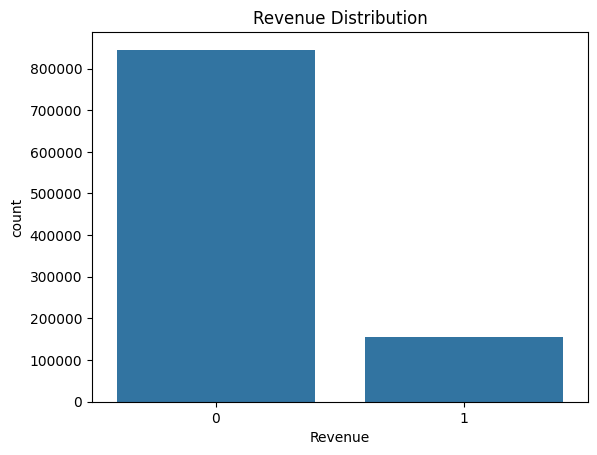

In [52]:
sns.countplot(x='Revenue', data=df)
plt.title("Revenue Distribution")
plt.show()

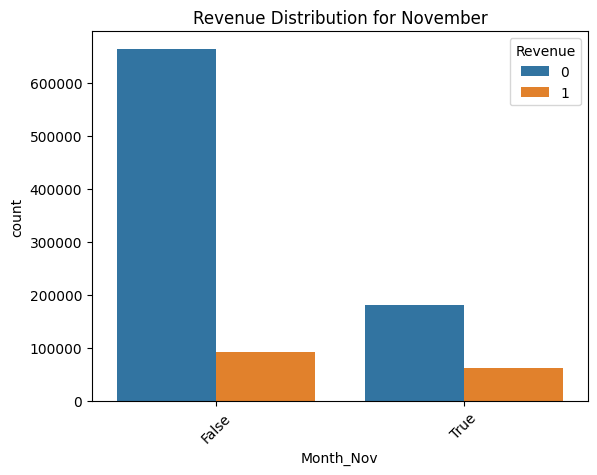

In [55]:
sns.countplot(x='Month_Nov', hue='Revenue', data=df)
plt.title("Revenue Distribution for November")
plt.xticks(rotation=45)
plt.show()

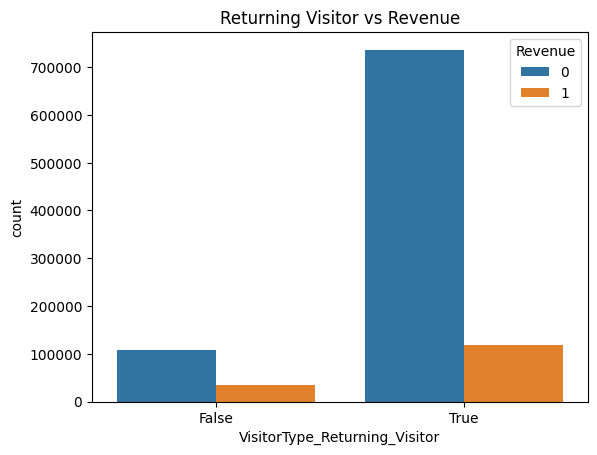

In [57]:
sns.countplot(x='VisitorType_Returning_Visitor', hue='Revenue', data=df)
plt.title("Returning Visitor vs Revenue")
plt.show()

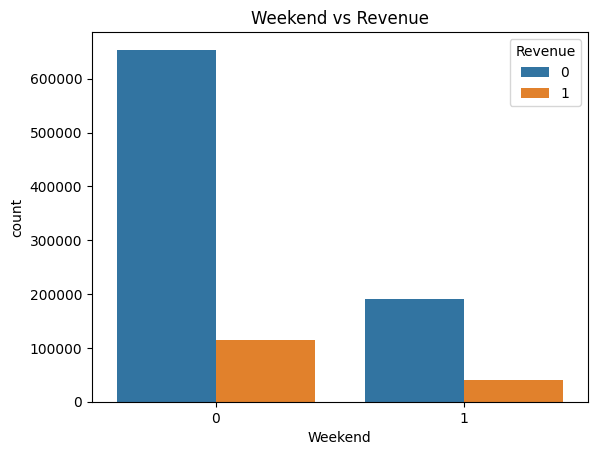

In [58]:
sns.countplot(x='Weekend', hue='Revenue', data=df)
plt.title("Weekend vs Revenue")
plt.show()

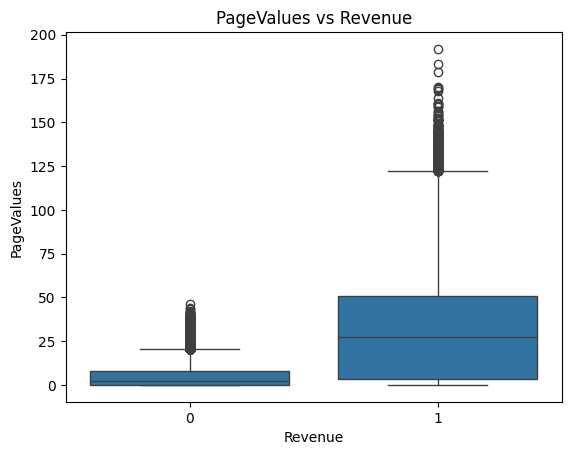

In [60]:
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title("PageValues vs Revenue")
plt.show()

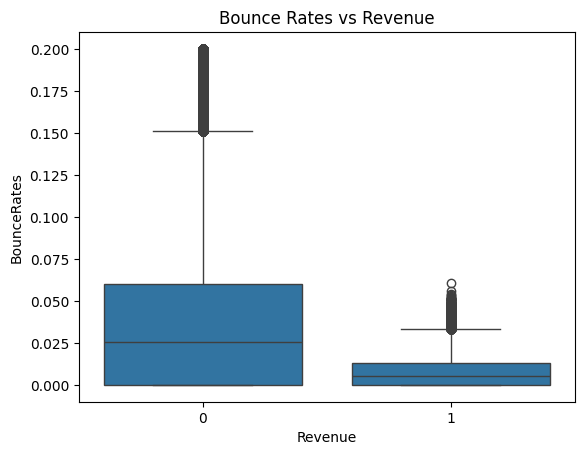

In [61]:
sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.title("Bounce Rates vs Revenue")
plt.show()

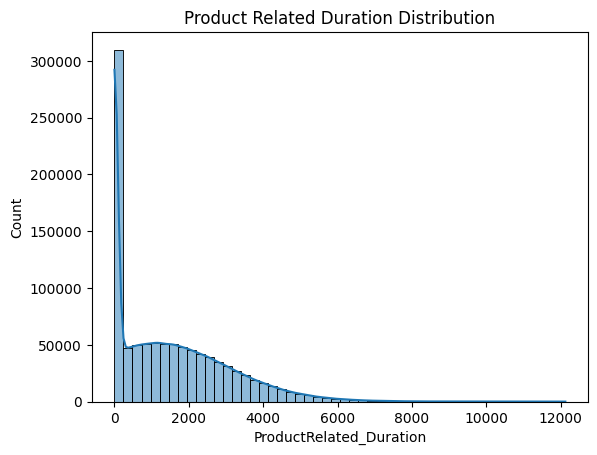

In [62]:
sns.histplot(df['ProductRelated_Duration'], bins=50, kde=True)
plt.title("Product Related Duration Distribution")
plt.show()

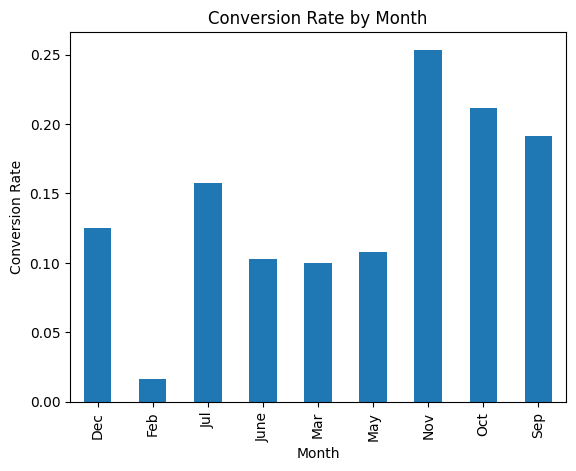

In [65]:
month_conversion_rates = {}
month_columns = [col for col in df.columns if col.startswith('Month_')]

for month_col in month_columns:

    conversion_rate = df[df[month_col] == 1]['Revenue'].mean()

    month_name = month_col.replace('Month_', '')
    month_conversion_rates[month_name] = conversion_rate

conversion_rate_series = pd.Series(month_conversion_rates)

conversion_rate_series.plot(kind='bar')
plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate")
plt.xlabel("Month")
plt.show()

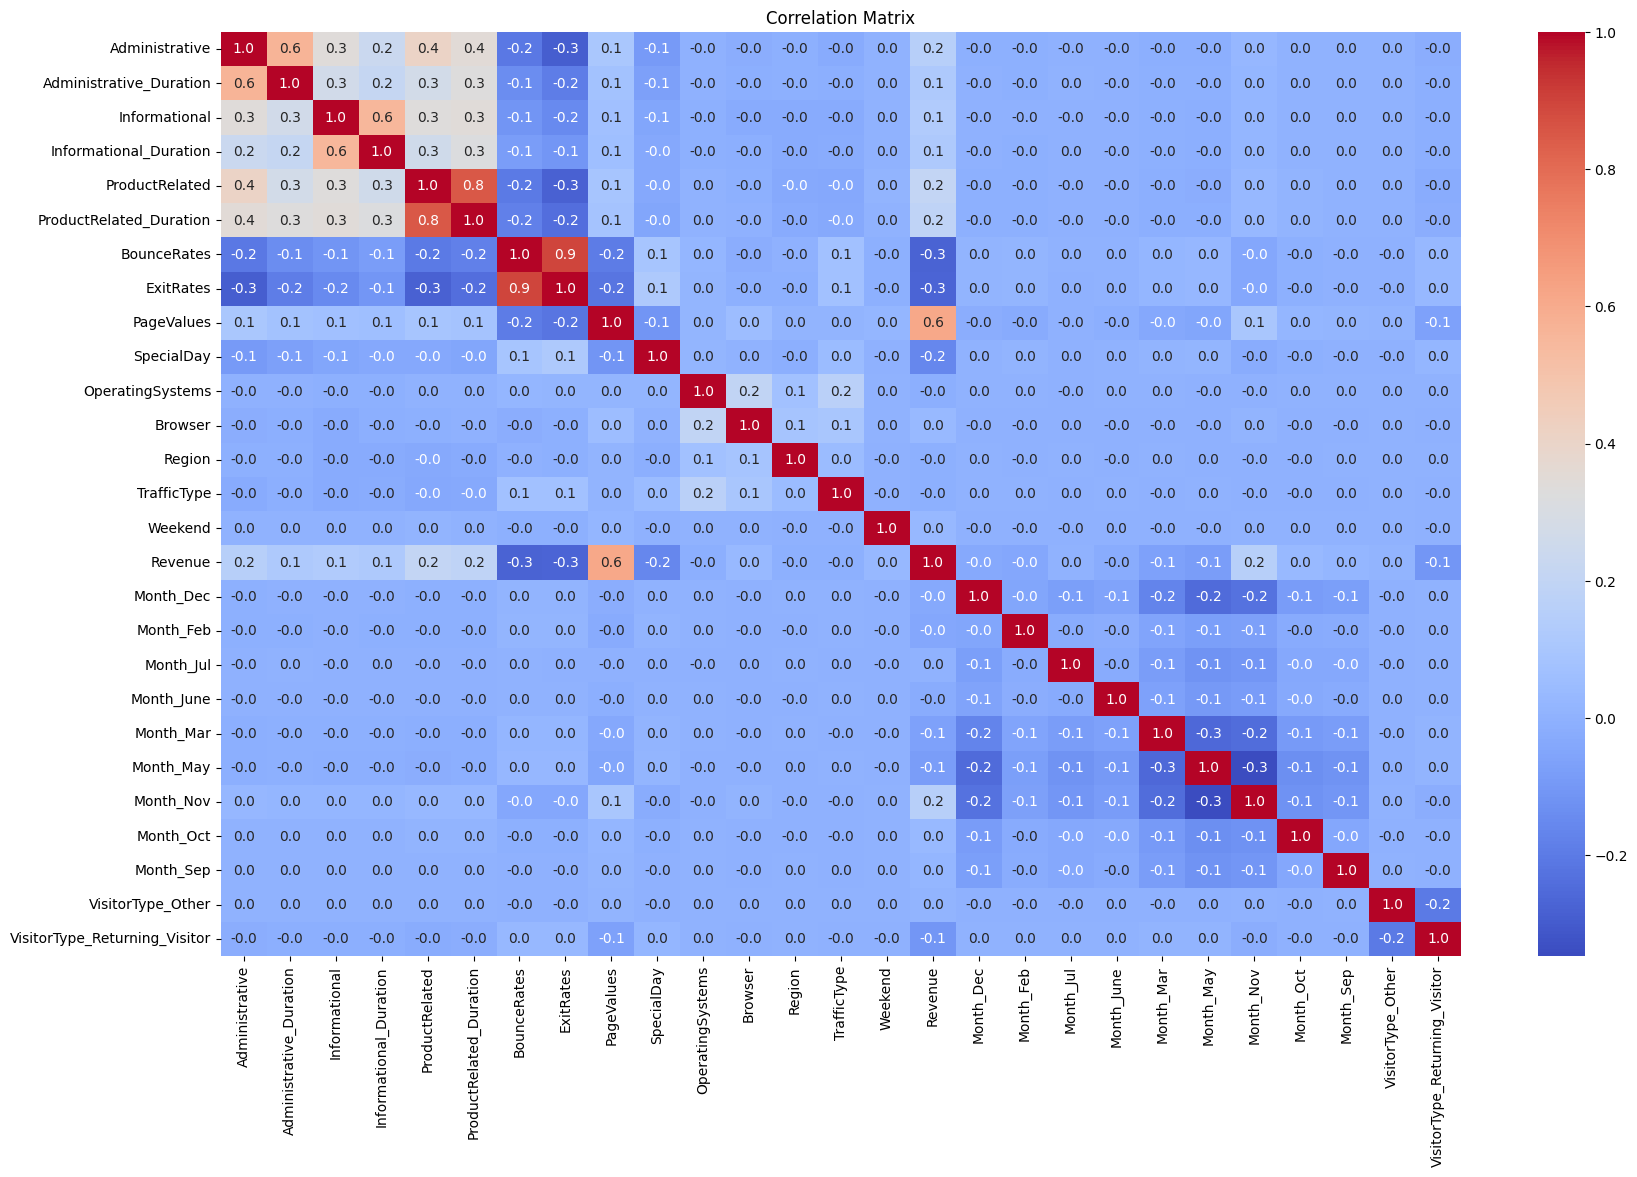

In [66]:
plt.figure(figsize=(20,12))
cm=df.corr()
sns.heatmap(cm,annot=True,fmt=".1f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [67]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.000000,0,0.000000,0,0.000000,0.016765,0.085003,3.191731,0.000000,...,False,False,False,False,False,True,False,False,False,True
1,3,140.433150,0,121.793138,55,2333.187358,0.000000,0.034682,0.000000,0.221186,...,False,False,False,False,False,False,False,False,False,True
2,2,169.063012,1,72.697027,23,1448.426947,0.068493,0.075369,0.000000,0.000000,...,False,False,False,False,False,False,False,True,False,True
3,4,129.698301,1,118.581521,53,1238.760755,0.024336,0.049339,14.476824,0.124415,...,False,False,False,False,True,False,False,False,False,False
4,2,214.526081,2,235.043689,37,297.590433,0.001517,0.018661,37.270547,0.071883,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999994,5,145.040629,0,116.976540,111,3390.402343,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,True,False,False,False,False,False
999995,0,0.000000,1,82.310616,0,0.000000,0.128995,0.183235,0.000000,0.216012,...,False,False,False,True,False,False,False,False,False,True
999996,2,68.850234,0,0.000000,13,0.000000,0.072351,0.085056,8.755833,0.000000,...,False,False,False,True,False,False,False,False,False,True
999997,5,0.000000,0,97.971941,35,1696.862699,0.024662,0.051551,11.351870,0.198211,...,False,False,False,False,True,False,False,False,False,True


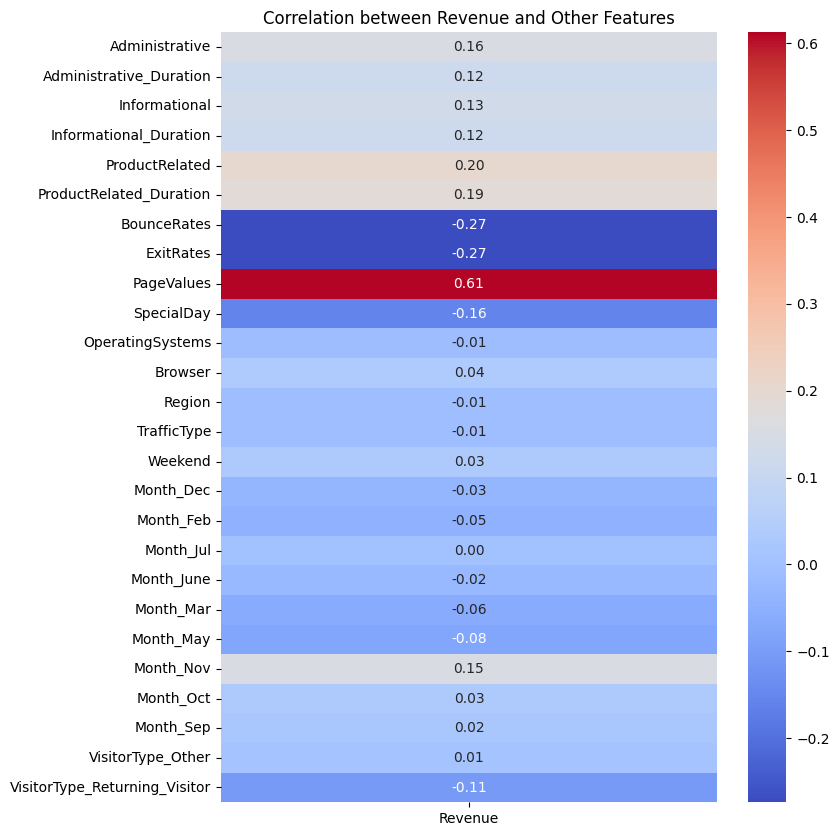

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Revenue"]=df["Revenue"].astype(int)

target_corr=df.corr()["Revenue"]

target_corr=target_corr.drop("Revenue")

plt.figure(figsize=(8,10))
sns.heatmap(target_corr.to_frame(), annot=True, fmt=".2f", cmap="coolwarm",
            cbar=True, annot_kws={"size":10})

plt.title("Correlation between Revenue and Other Features")
plt.show()

<Axes: >

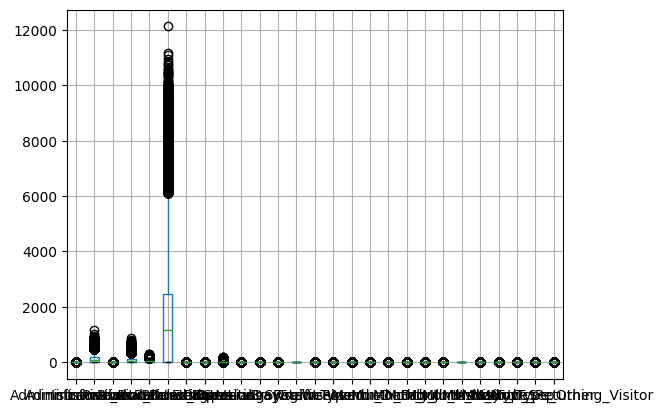

In [69]:
df.boxplot()

In [71]:
def remove_outliers_selected(df,cols):
    for col in cols:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR
        df=df[(df[col]>=lower)&(df[col]<=upper)]
    return df

continuous_cols=['Administrative_Duration','Informational_Duration','ProductRelated_Duration','BounceRates','ExitRates','PageValues','SpecialDay']
df=remove_outliers_selected(df,continuous_cols)

In [72]:
df.shape

(853601, 27)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 853601 entries, 0 to 999998
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Administrative                 853601 non-null  int64  
 1   Administrative_Duration        853601 non-null  float64
 2   Informational                  853601 non-null  int64  
 3   Informational_Duration         853601 non-null  float64
 4   ProductRelated                 853601 non-null  int64  
 5   ProductRelated_Duration        853601 non-null  float64
 6   BounceRates                    853601 non-null  float64
 7   ExitRates                      853601 non-null  float64
 8   PageValues                     853601 non-null  float64
 9   SpecialDay                     853601 non-null  float64
 10  OperatingSystems               853601 non-null  int64  
 11  Browser                        853601 non-null  int64  
 12  Region                         8536

In [74]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=["Administrative","Administrative_Duration","Informational","Informational_Duration","ProductRelated","ProductRelated_Duration","BounceRates","ExitRates","PageValues","SpecialDay"]

scaler=MinMaxScaler()
df[features]=scaler.fit_transform(df[features])

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.123673,0.504589,0.122405,0.000000,...,False,False,False,False,False,True,False,False,False,True
1,0.15,0.282584,0.000000,0.385538,0.257009,0.392599,0.000000,0.205875,0.000000,0.441496,...,False,False,False,False,False,False,False,False,False,True
2,0.10,0.340194,0.166667,0.230123,0.107477,0.243723,0.505279,0.447396,0.000000,0.000000,...,False,False,False,False,False,False,False,True,False,True
3,0.20,0.260983,0.166667,0.375371,0.247664,0.208443,0.179528,0.292882,0.555195,0.248337,...,False,False,False,False,True,False,False,False,False,False
5,0.00,0.000000,0.000000,0.201096,0.000000,0.335082,0.922382,0.765785,0.000000,0.479110,...,False,False,False,False,False,False,False,False,False,True


In [75]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.123673,0.504589,0.122405,0.000000,...,False,False,False,False,False,True,False,False,False,True
1,0.15,0.282584,0.000000,0.385538,0.257009,0.392599,0.000000,0.205875,0.000000,0.441496,...,False,False,False,False,False,False,False,False,False,True
2,0.10,0.340194,0.166667,0.230123,0.107477,0.243723,0.505279,0.447396,0.000000,0.000000,...,False,False,False,False,False,False,False,True,False,True
3,0.20,0.260983,0.166667,0.375371,0.247664,0.208443,0.179528,0.292882,0.555195,0.248337,...,False,False,False,False,True,False,False,False,False,False
5,0.00,0.000000,0.000000,0.201096,0.000000,0.335082,0.922382,0.765785,0.000000,0.479110,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999993,0.10,0.000000,0.000000,0.383979,0.228972,0.393682,0.598643,0.697222,0.059921,0.260149,...,False,False,False,False,True,False,False,False,False,True
999994,0.25,0.291855,0.000000,0.370291,0.518692,0.570494,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,True,False,False,False,False,False
999996,0.10,0.138542,0.000000,0.000000,0.060748,0.000000,0.533734,0.504901,0.335791,0.000000,...,False,False,False,True,False,False,False,False,False,True
999997,0.25,0.000000,0.000000,0.310131,0.163551,0.285527,0.181930,0.306014,0.435351,0.395638,...,False,False,False,False,True,False,False,False,False,True


In [77]:
df["Revenue"] = df["Revenue"].astype(int)

X = df[["Administrative","ProductRelated","BounceRates","ExitRates","PageValues"]]
y = df["Revenue"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.92
